In [1]:
import numpy as np
import pandas as pd
import dill 
from tqdm import tqdm
import time
from scipy.stats import qmc
import random
import scipy.stats as stats
from scipy.stats import multivariate_normal

from Forward_model.generate_IC_fixed_grid import get_generate_IC_fixed_grid
from Forward_model.solution_using_FD import get_solution_using_FD
from Forward_model.linear_interpolation import interpolate_linear,interpolate_linear_fill_value
import os

from sklearn.gaussian_process.kernels import Matern
from Forward_model.cubic_spline_interpolation import interpolate_cubicSpline

In [2]:
import dill
import numpy as np

with open('Forward_model/IC_ws64_wb0_tb14_H2782_a24634_ic.pkl', 'rb') as f:
    ics = dill.load(f)

In [3]:
import matplotlib.pyplot as plt

Artificial time series

In [4]:
all_signals_1_to_4=np.load('Data/Gaussian_pulse_signals/time_series_used/all_signals_1_to_4.npy')
signal_1 = all_signals_1_to_4[0]
signal_2 = all_signals_1_to_4[1]
signal_3 = all_signals_1_to_4[2]
signal_4 = all_signals_1_to_4[3]

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.gaussian_process.kernels import Matern

def kernel_based_model(t, t_i, alpha_i, length_scale, nu):

    t = np.atleast_1d(t).reshape(-1, 1)
    t_i = np.array(t_i).reshape(-1, 1)
    alpha_i = np.array(alpha_i).reshape(-1)

    kernel = Matern(length_scale=length_scale, nu=nu)

    K = kernel(t, t_i)

    st = K @ alpha_i 
    
    return st

def generate_surface_temperature(alpha_list,time_list,time_steps,pom,scale_value):
    
    t_i = time_list 
    
    alpha_i = alpha_list

    t_eval =time_steps
    st_values = kernel_based_model(t_eval, t_i, alpha_i, length_scale=scale_value, nu=np.inf)+pom

    return  st_values.flatten()


In [6]:
   
def loss_fn1(weights):
    y_hat = generate_surface_temperature(weights,t_init,annual_time_steps,pom,scale_value)
    return np.mean((y - y_hat)**2)

y = signal_1+45.0

all_no_of_kernels=[20,40,60,80,100]
all_scale_values=[10,20,30]

dict_signal_1={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
    
        
        t_init = np.linspace(0, 499, no_of_kernels)  
        pom=0
        annual_time_steps=np.arange(0,500,1)
            
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        
        y_hat = generate_surface_temperature(opt_weights,t_init,annual_time_steps,pom,scale_value)

        dict_signal_1[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_1[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights



In [7]:
y = signal_2+45.0

all_no_of_kernels=[20,40,60,80,100]
all_scale_values=[10,20,30]

dict_signal_2={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
    
        
        t_init = np.linspace(0, 499, no_of_kernels)  
        pom=0
        annual_time_steps=np.arange(0,500,1)
            
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        
        y_hat = generate_surface_temperature(opt_weights,t_init,annual_time_steps,pom,scale_value)

        dict_signal_2[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_2[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights
        


In [8]:
y = signal_3+45.0

all_no_of_kernels=[20,40,60,80,100]
all_scale_values=[10,20,30]

dict_signal_3={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
    
        
        t_init = np.linspace(0, 499, no_of_kernels)  
        pom=0
        annual_time_steps=np.arange(0,500,1)
            
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        
        y_hat = generate_surface_temperature(opt_weights,t_init,annual_time_steps,pom,scale_value)

        dict_signal_3[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_3[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights


In [9]:
y = signal_4+45.0

all_no_of_kernels=[20,40,60,80,100]
all_scale_values=[10,20,30]

dict_signal_4={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
    
        
        t_init = np.linspace(0, 499, no_of_kernels)  
        pom=0
        annual_time_steps=np.arange(0,500,1)
            
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        
        y_hat = generate_surface_temperature(opt_weights,t_init,annual_time_steps,pom,scale_value)

        dict_signal_4[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_4[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights
        

In [10]:
all_no_of_kernels=[20,40,60,80,100]
all_scale_values=[10,20,30]

with open("Results/dict_signal_1.pkl", "rb") as f1:
    dict_signal_1=dill.load(f1)

with open("Results/dict_signal_2.pkl", "rb") as f2:
    dict_signal_2=dill.load(f2)

with open("Results/dict_signal_3.pkl", "rb") as f3:
    dict_signal_3=dill.load(f3)

with open("Results/dict_signal_4.pkl", "rb") as f4:
    dict_signal_4=dill.load(f4)

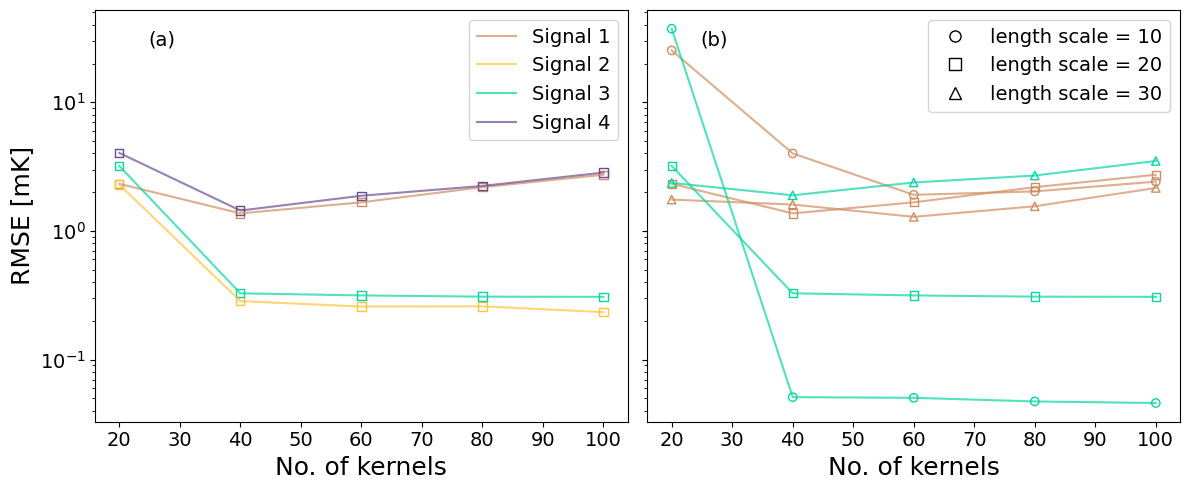

In [13]:
from matplotlib.lines import Line2D
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)
alphas=[1,1,1,1]
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
markers=['o','s','^']
subplotleftlabels=['(a)','(b)']
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

rmse_diff1=[]
rmse_diff2=[]
rmse_diff3=[]
rmse_diff4=[]
n=1
scale_value=20
for no_of_kernels in all_no_of_kernels:
   
    rmse_diff1.append(np.sqrt(np.mean((dict_signal_1[f"difference_sc{scale_value}_no{no_of_kernels}"])**2)))
    rmse_diff2.append(np.sqrt(np.mean((dict_signal_2[f"difference_sc{scale_value}_no{no_of_kernels}"])**2)))
    rmse_diff3.append(np.sqrt(np.mean((dict_signal_3[f"difference_sc{scale_value}_no{no_of_kernels}"])**2)))
    rmse_diff4.append(np.sqrt(np.mean((dict_signal_4[f"difference_sc{scale_value}_no{no_of_kernels}"])**2)))

axs[0].scatter(all_no_of_kernels, np.array(rmse_diff1)*1000, alpha=1, marker=markers[n], color=colors[0],facecolors='none')
axs[0].scatter(all_no_of_kernels, np.array(rmse_diff2)*1000, alpha=1, marker=markers[n], color=colors[1],facecolors='none')
axs[0].scatter(all_no_of_kernels, np.array(rmse_diff3)*1000, alpha=1, marker=markers[n], color=colors[2],facecolors='none')
axs[0].scatter(all_no_of_kernels, np.array(rmse_diff4)*1000, alpha=1, marker=markers[n], color=colors[3],facecolors='none')

axs[0].plot(all_no_of_kernels, np.array(rmse_diff1)*1000, alpha=0.7, color=colors[0], label='Signal 1')
axs[0].plot(all_no_of_kernels, np.array(rmse_diff2)*1000, alpha=0.7,color=colors[1], label='Signal 2')
axs[0].plot(all_no_of_kernels, np.array(rmse_diff3)*1000, alpha=0.7,color=colors[2], label='Signal 3')
axs[0].plot(all_no_of_kernels, np.array(rmse_diff4)*1000, alpha=0.7,  color=colors[3], label='Signal 4')

axs[0].set_yscale('log')
axs[0].set_xlabel('No. of kernels', fontsize=18)
axs[0].set_ylabel('RMSE [mK]', fontsize=18)
axs[0].legend(loc='upper right',fontsize=14)
axs[0].text(0.1, 0.95, subplotleftlabels[0], horizontalalignment='left', verticalalignment='top', transform=axs[0].transAxes,fontsize=14)
  
# --- all scales, signal1 vs no. of kernels ---

rmse_all_scales_sig1=np.zeros((len(all_scale_values),len(all_no_of_kernels)))
rmse_all_scales_sig3=np.zeros((len(all_scale_values),len(all_no_of_kernels)))
sc=0  
for scale_value in all_scale_values:
 
    rmse_diff_1=[]
    # rmse_diff_2=[]
    rmse_diff_3=[]
    for no_of_kernels in all_no_of_kernels:
        rmse_diff_1.append(np.sqrt(np.mean((dict_signal_1[f"difference_sc{scale_value}_no{no_of_kernels}"])**2)))
        rmse_diff_3.append(np.sqrt(np.mean((dict_signal_3[f"difference_sc{scale_value}_no{no_of_kernels}"])**2)))
    
    
    rmse_all_scales_sig1[sc]=rmse_diff_1
    # rmse_all_scales_sig2[sc]=rmse_diff_2
    rmse_all_scales_sig3[sc]=rmse_diff_3
    sc=sc+1


axs[1].scatter(all_no_of_kernels, rmse_all_scales_sig1[0,:]*1000, alpha=1, marker=markers[0], color=colors[0],facecolors='none', label='length scale = 10')
axs[1].plot(all_no_of_kernels, rmse_all_scales_sig1[0,:]*1000, alpha=0.7, color=colors[0])

axs[1].scatter(all_no_of_kernels, rmse_all_scales_sig1[1,:]*1000, alpha=1, marker=markers[1], color=colors[0],facecolors='none', label='length scale = 20')
axs[1].plot(all_no_of_kernels, rmse_all_scales_sig1[1,:]*1000, alpha=0.7, color=colors[0])

axs[1].scatter(all_no_of_kernels, rmse_all_scales_sig1[2,:]*1000, alpha=1, marker=markers[2], color=colors[0],facecolors='none', label='length scale = 30')
axs[1].plot(all_no_of_kernels, rmse_all_scales_sig1[2,:]*1000, alpha=0.7, color=colors[0])

axs[1].scatter(all_no_of_kernels, rmse_all_scales_sig3[0,:]*1000, alpha=1, marker=markers[0], color=colors[2],facecolors='none')
axs[1].plot(all_no_of_kernels, rmse_all_scales_sig3[0,:]*1000, alpha=0.7, color=colors[2])

axs[1].scatter(all_no_of_kernels, rmse_all_scales_sig3[1,:]*1000, alpha=1, marker=markers[1], color=colors[2],facecolors='none')
axs[1].plot(all_no_of_kernels, rmse_all_scales_sig3[1,:]*1000, alpha=0.7, color=colors[2])

axs[1].scatter(all_no_of_kernels, rmse_all_scales_sig3[2,:]*1000, alpha=1, marker=markers[2], color=colors[2],facecolors='none')
axs[1].plot(all_no_of_kernels, rmse_all_scales_sig3[2,:]*1000, alpha=0.7, color=colors[2])



axs[1].set_yscale('log')
axs[1].set_xlabel('No. of kernels', fontsize=18)
custom_handles = [
    Line2D([0], [0], marker='o', color='black', label='length scale = 10', markersize=8, linestyle='None',markerfacecolor='none'),
    Line2D([0], [0], marker='s', color='black', label='length scale = 20', markersize=8, linestyle='None',markerfacecolor='none'),
    Line2D([0], [0], marker='^', color='black', label='length scale = 30', markersize=8, linestyle='None',markerfacecolor='none')
]

axs[1].legend(handles=custom_handles, fontsize=14, loc='upper right')
axs[1].text(0.1, 0.95, subplotleftlabels[1], horizontalalignment='left', verticalalignment='top', transform=axs[1].transAxes,fontsize=14)
    
plt.tight_layout()
# plt.savefig('Figures/fig_kernel_setup.png', dpi=300)



In [14]:
signal_1= np.load('Data/Gaussian_pulse_signals/time_series_used/all_signals_1_to_4.npy')[0] 
signal_2= np.load('Data/Gaussian_pulse_signals/time_series_used/all_signals_1_to_4.npy')[1] 
signal_3= np.load('Data/Gaussian_pulse_signals/time_series_used/all_signals_1_to_4.npy')[2] 
signal_4= np.load('Data/Gaussian_pulse_signals/time_series_used/all_signals_1_to_4.npy')[3] 

In [15]:
Artificial_signal_1_60knos_40eq_1mK_qmean=np.load('Results/Artificial_signal_1_60knos 40eq_1mK_qmean.npy')
Artificial_signal_1_60knos_40eq_1mK_lower_bound=np.load('Results/Artificial_signal_1_60knos 40eq_1mK_lower_bound.npy')
Artificial_signal_1_60knos_40eq_1mK_upper_bound=np.load('Results/Artificial_signal_1_60knos 40eq_1mK_upper_bound.npy')

Artificial_signal_2_60knos_40eq_1mK_qmean=np.load('Results/Artificial_signal_2_60knos 40eq_1mK_qmean.npy')
Artificial_signal_2_60knos_40eq_1mK_lower_bound=np.load('Results/Artificial_signal_2_60knos 40eq_1mK_lower_bound.npy')
Artificial_signal_2_60knos_40eq_1mK_upper_bound=np.load('Results/Artificial_signal_2_60knos 40eq_1mK_upper_bound.npy')

Artificial_signal_3_60knos_40eq_1mK_qmean=np.load('Results/Artificial_signal_3_60knos 40eq_1mK_qmean.npy')
Artificial_signal_3_60knos_40eq_1mK_lower_bound=np.load('Results/Artificial_signal_3_60knos 40eq_1mK_lower_bound.npy')
Artificial_signal_3_60knos_40eq_1mK_upper_bound=np.load('Results/Artificial_signal_3_60knos 40eq_1mK_upper_bound.npy')

Artificial_signal_4_60knos_40eq_1mK_qmean=np.load('Results/Artificial_signal_4_60knos 40eq_1mK_qmean.npy')
Artificial_signal_4_60knos_40eq_1mK_lower_bound=np.load('Results/Artificial_signal_4_60knos 40eq_1mK_lower_bound.npy')
Artificial_signal_4_60knos_40eq_1mK_upper_bound=np.load('Results/Artificial_signal_4_60knos 40eq_1mK_upper_bound.npy')



In [16]:
upper_bound_artificial_signal_1_40eq_1mK=np.load('Results/Artificial_signal_1_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_1_40eq_1mK=np.load('Results/Artificial_signal_1_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_1_40eq_1mK=np.load('Results/Artificial_signal_1_40eq_1mK_qmean.npy')

upper_bound_artificial_signal_2_40eq_1mK=np.load('Results/Artificial_signal_2_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_2_40eq_1mK=np.load('Results/Artificial_signal_2_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_2_40eq_1mK=np.load('Results/Artificial_signal_2_40eq_1mK_qmean.npy')

upper_bound_artificial_signal_3_40eq_1mK=np.load('Results/Artificial_signal_3_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_3_40eq_1mK=np.load('Results/Artificial_signal_3_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_3_40eq_1mK=np.load('Results/Artificial_signal_3_40eq_1mK_qmean.npy')

upper_bound_artificial_signal_4_40eq_1mK=np.load('Results/Artificial_signal_4_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_4_40eq_1mK=np.load('Results/Artificial_signal_4_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_4_40eq_1mK=np.load('Results/Artificial_signal_4_40eq_1mK_qmean.npy')

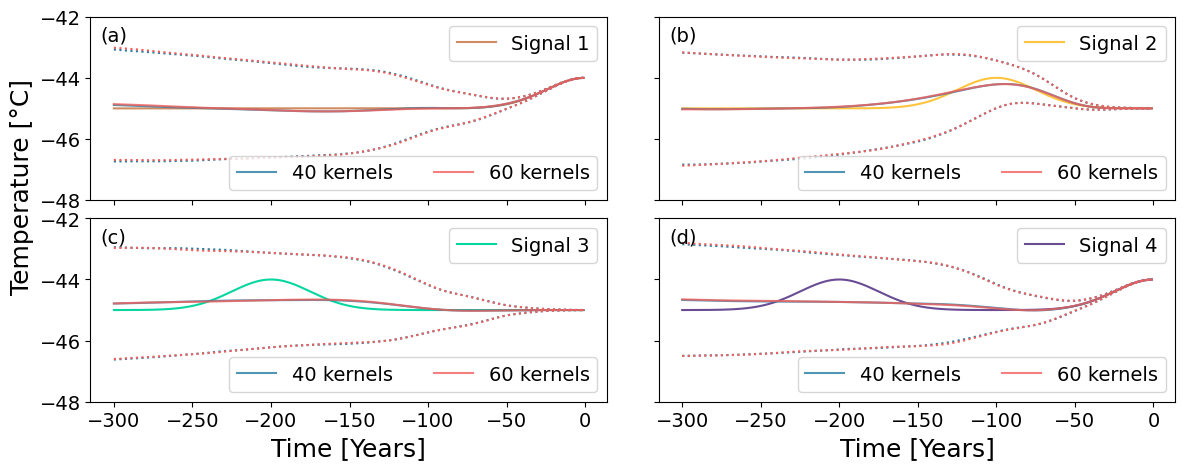

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

t_annual_500yr=np.arange(0,500,1)

x1=t_annual_500yr -500
signals = [
    signal_1,
    signal_2,
    signal_3,
    signal_4,
]


others = [
    [q_mean_artificial_signal_1_40eq_1mK, Artificial_signal_1_60knos_40eq_1mK_qmean],
    [q_mean_artificial_signal_2_40eq_1mK, Artificial_signal_2_60knos_40eq_1mK_qmean],
    [q_mean_artificial_signal_3_40eq_1mK, Artificial_signal_3_60knos_40eq_1mK_qmean],
    [q_mean_artificial_signal_4_40eq_1mK, Artificial_signal_4_60knos_40eq_1mK_qmean],
]
ci_upper = [
    [upper_bound_artificial_signal_1_40eq_1mK, Artificial_signal_1_60knos_40eq_1mK_upper_bound],
    [upper_bound_artificial_signal_2_40eq_1mK, Artificial_signal_2_60knos_40eq_1mK_upper_bound],
    [upper_bound_artificial_signal_3_40eq_1mK, Artificial_signal_3_60knos_40eq_1mK_upper_bound],
    [upper_bound_artificial_signal_4_40eq_1mK, Artificial_signal_4_60knos_40eq_1mK_upper_bound],
]

ci_lower= [
    [lower_bound_artificial_signal_1_40eq_1mK, Artificial_signal_1_60knos_40eq_1mK_lower_bound],
    [lower_bound_artificial_signal_2_40eq_1mK, Artificial_signal_2_60knos_40eq_1mK_lower_bound],
    [lower_bound_artificial_signal_3_40eq_1mK, Artificial_signal_3_60knos_40eq_1mK_lower_bound],
    [lower_bound_artificial_signal_4_40eq_1mK, Artificial_signal_4_60knos_40eq_1mK_lower_bound],
]


labels  = ['Signal 1', 'Signal 2', 'Signal 3', 'Signal 4']
sublabels  = ['40 kernels', '60 kernels']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
recon_colors  = ['#247ba0','#f25f5c']
subplotlabels  = ['(a)', '(b)', '(c)', '(d)']

# -------------------
# Create simple 4x1 figure
# -------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 5), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

axs = axs.flatten() 

for i, ax in enumerate(axs):
    # Plot main signal
    line_signal,=ax.plot(x1[-300:], signals[i][-300:], color=colors[i], label=labels[i])
    first_legend = ax.legend(handles=[line_signal], loc='upper right',fontsize=14)
    ax.add_artist(first_legend) 
    
    # Plot reconstructions
    line_legend=[]
    for j in range(len(others[i])):
        line_1,=ax.plot(x1[-300:], others[i][j][-300:], color=recon_colors[j], alpha=0.8, label=sublabels[j])
        ax.plot(x1[-300:], ci_upper[i][j][-300:], color=recon_colors[j], linestyle='dotted')
        ax.plot(x1[-300:], ci_lower[i][j][-300:], color=recon_colors[j], linestyle='dotted')
        line_legend.append(line_1)

    # Subplot label
    ax.set_ylim(-48, -42)
    ax.legend(handles=line_legend,loc='lower right',fontsize=14, mode = "expand", ncol = 2, bbox_to_anchor=(0.25, 0, 0.75, 1))
    ax.text(0.02, 0.95, subplotlabels[i], transform=ax.transAxes, fontsize=14, verticalalignment='top')

axs[3].set_xlabel('Time [Years]', fontsize=18)
axs[2].set_xlabel('Time [Years]', fontsize=18)
# axs[0].set_ylabel('Temperature [°C]', fontsize=18)
axs[2].set_ylabel('                               Temperature [°C]', fontsize=18)

# plt.savefig('Figures/fig_kernel_sensitivity.png', dpi=300)
plt.show()

Results 4.3. Reconstruction quality: measurement density 

In [18]:
upper_bound_artificial_signal_1_40eq_10mK=np.load('Results/Artificial_signal_1_40eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_1_40eq_10mK=np.load('Results/Artificial_signal_1_40eq_10mK_lower_bound.npy')
q_mean_artificial_signal_1_40eq_10mK=np.load('Results/Artificial_signal_1_40eq_10mK_qmean.npy')

upper_bound_artificial_signal_2_40eq_10mK=np.load('Results/Artificial_signal_2_40eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_2_40eq_10mK=np.load('Results/Artificial_signal_2_40eq_10mK_lower_bound.npy')
q_mean_artificial_signal_2_40eq_10mK=np.load('Results/Artificial_signal_2_40eq_10mK_qmean.npy')

upper_bound_artificial_signal_3_40eq_10mK=np.load('Results/Artificial_signal_3_40eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_3_40eq_10mK=np.load('Results/Artificial_signal_3_40eq_10mK_lower_bound.npy')
q_mean_artificial_signal_3_40eq_10mK=np.load('Results/Artificial_signal_3_40eq_10mK_qmean.npy')

upper_bound_artificial_signal_4_40eq_10mK=np.load('Results/Artificial_signal_4_40eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_4_40eq_10mK=np.load('Results/Artificial_signal_4_40eq_10mK_lower_bound.npy')
q_mean_artificial_signal_4_40eq_10mK=np.load('Results/Artificial_signal_4_40eq_10mK_qmean.npy')


upper_bound_artificial_signal_1_30eq_10mK=np.load('Results/Artificial_signal_1_30eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_1_30eq_10mK=np.load('Results/Artificial_signal_1_30eq_10mK_lower_bound.npy')
q_mean_artificial_signal_1_30eq_10mK=np.load('Results/Artificial_signal_1_30eq_10mK_qmean.npy')

upper_bound_artificial_signal_2_30eq_10mK=np.load('Results/Artificial_signal_2_30eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_2_30eq_10mK=np.load('Results/Artificial_signal_2_30eq_10mK_lower_bound.npy')
q_mean_artificial_signal_2_30eq_10mK=np.load('Results/Artificial_signal_2_30eq_10mK_qmean.npy')

upper_bound_artificial_signal_3_30eq_10mK=np.load('Results/Artificial_signal_3_30eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_3_30eq_10mK=np.load('Results/Artificial_signal_3_30eq_10mK_lower_bound.npy')
q_mean_artificial_signal_3_30eq_10mK=np.load('Results/Artificial_signal_3_30eq_10mK_qmean.npy')

upper_bound_artificial_signal_4_30eq_10mK=np.load('Results/Artificial_signal_4_30eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_4_30eq_10mK=np.load('Results/Artificial_signal_4_30eq_10mK_lower_bound.npy')
q_mean_artificial_signal_4_30eq_10mK=np.load('Results/Artificial_signal_4_30eq_10mK_qmean.npy')


upper_bound_artificial_signal_1_20eq_10mK=np.load('Results/Artificial_signal_1_20eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_1_20eq_10mK=np.load('Results/Artificial_signal_1_20eq_10mK_lower_bound.npy')
q_mean_artificial_signal_1_20eq_10mK=np.load('Results/Artificial_signal_1_20eq_10mK_qmean.npy')

upper_bound_artificial_signal_2_20eq_10mK=np.load('Results/Artificial_signal_2_20eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_2_20eq_10mK=np.load('Results/Artificial_signal_2_20eq_10mK_lower_bound.npy')
q_mean_artificial_signal_2_20eq_10mK=np.load('Results/Artificial_signal_2_20eq_10mK_qmean.npy')

upper_bound_artificial_signal_3_20eq_10mK=np.load('Results/Artificial_signal_3_20eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_3_20eq_10mK=np.load('Results/Artificial_signal_3_20eq_10mK_lower_bound.npy')
q_mean_artificial_signal_3_20eq_10mK=np.load('Results/Artificial_signal_3_20eq_10mK_qmean.npy')

upper_bound_artificial_signal_4_20eq_10mK=np.load('Results/Artificial_signal_4_20eq_10mK_upper_bound.npy')
lower_bound_artificial_signal_4_20eq_10mK=np.load('Results/Artificial_signal_4_20eq_10mK_lower_bound.npy')
q_mean_artificial_signal_4_20eq_10mK=np.load('Results/Artificial_signal_4_20eq_10mK_qmean.npy')


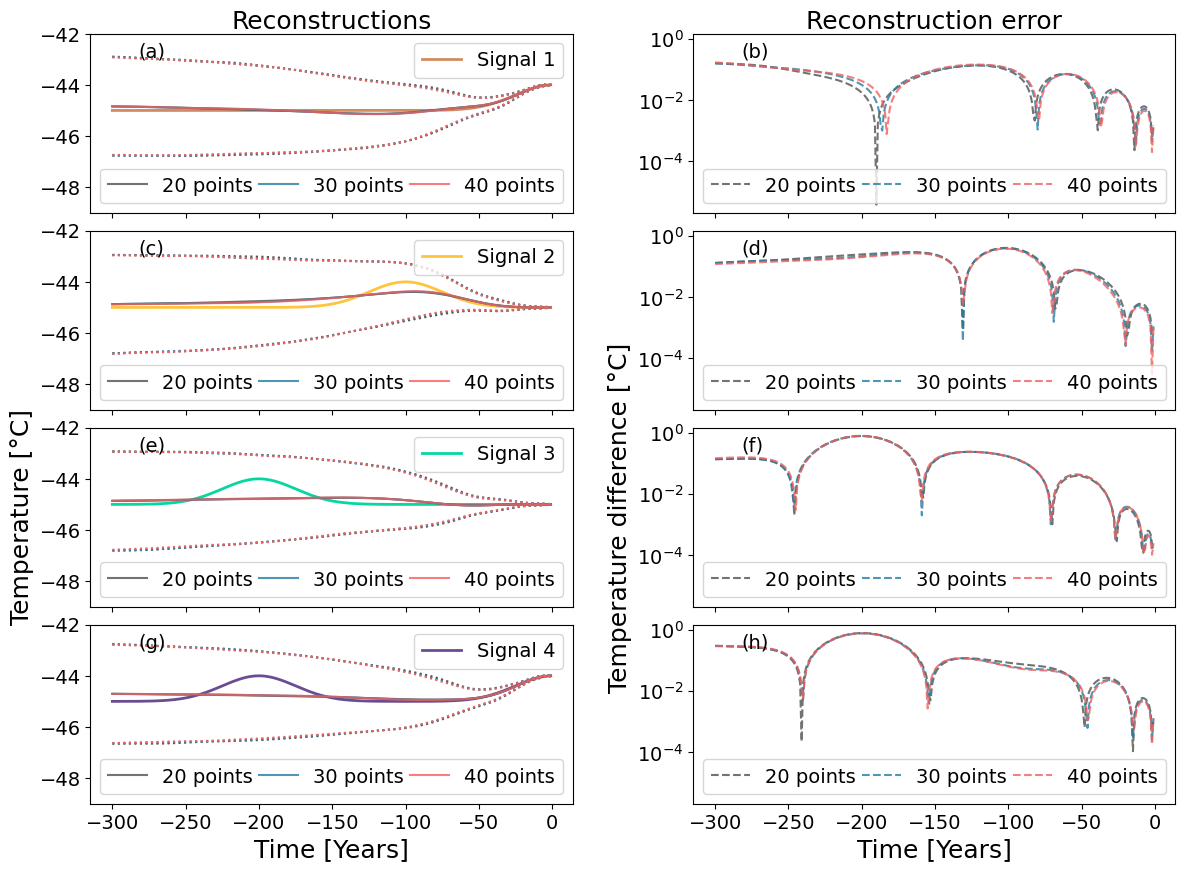

In [19]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

t_annual_500yr=np.arange(0,500,1)
signals_annual = [signal_1, signal_2, signal_3, signal_4]

x1=t_annual_500yr -500
signals = [
    signal_1,
    signal_2,
    signal_3,
    signal_4,
]

labels  = ['Signal 1', 'Signal 2', 'Signal 3', 'Signal 4']
sublabels  = ['20 points', '30 points', '40 points']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
recon_colors  = ['#50514f', '#247ba0','#f25f5c']
subplotleftlabels  = ['(a)', '(c)','(e)','(g)']
subplotrightlabels  = ['(b)','(d)','(f)','(h)']

others = [
    [q_mean_artificial_signal_1_20eq_10mK, q_mean_artificial_signal_1_30eq_10mK, q_mean_artificial_signal_1_40eq_10mK],
    [q_mean_artificial_signal_2_20eq_10mK, q_mean_artificial_signal_2_30eq_10mK, q_mean_artificial_signal_2_40eq_10mK],
    [q_mean_artificial_signal_3_20eq_10mK, q_mean_artificial_signal_3_30eq_10mK, q_mean_artificial_signal_3_40eq_10mK],
    [q_mean_artificial_signal_4_20eq_10mK, q_mean_artificial_signal_4_30eq_10mK, q_mean_artificial_signal_4_40eq_10mK],
]

ci_upper = [
    [upper_bound_artificial_signal_1_20eq_10mK, upper_bound_artificial_signal_1_30eq_10mK, upper_bound_artificial_signal_1_40eq_10mK],
    [upper_bound_artificial_signal_2_20eq_10mK, upper_bound_artificial_signal_2_30eq_10mK, upper_bound_artificial_signal_2_40eq_10mK],
    [upper_bound_artificial_signal_3_20eq_10mK, upper_bound_artificial_signal_3_30eq_10mK, upper_bound_artificial_signal_3_40eq_10mK],
    [upper_bound_artificial_signal_4_20eq_10mK, upper_bound_artificial_signal_4_30eq_10mK, upper_bound_artificial_signal_4_40eq_10mK],
]

ci_lower= [
    [lower_bound_artificial_signal_1_20eq_10mK, lower_bound_artificial_signal_1_30eq_10mK, lower_bound_artificial_signal_1_40eq_10mK],
    [lower_bound_artificial_signal_2_20eq_10mK, lower_bound_artificial_signal_2_30eq_10mK, lower_bound_artificial_signal_2_40eq_10mK],
    [lower_bound_artificial_signal_3_20eq_10mK, lower_bound_artificial_signal_3_30eq_10mK, lower_bound_artificial_signal_3_40eq_10mK],
    [lower_bound_artificial_signal_4_20eq_10mK, lower_bound_artificial_signal_4_30eq_10mK, lower_bound_artificial_signal_4_40eq_10mK],
]


fig = plt.figure(figsize=(14, 10))


# Outer layout: left (stacked) + right (single)
outer_gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# =========================
# LEFT PANEL: all 4 signals
# =========================
left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],
    hspace=0.1
)

left_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(left_gs[i],
                             sharex=left_axes[0],
                             sharey=left_axes[0])

    line_signal,=ax.plot(x1[-300:], signals[i][-300:],
            color=colors[i], label=labels[i], lw=2)

    first_legend = ax.legend(handles=[line_signal], loc='upper right',fontsize=14)
    ax.add_artist(first_legend)   
    

    line_1,=ax.plot(x1[-300:], others[i][0][-300:],
            color=recon_colors[0], label=sublabels[0],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')
    
    line_2,=ax.plot(x1[-300:], others[i][1][-300:],
            color=recon_colors[1], label=sublabels[1],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][1][-300:],
            color=recon_colors[1], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][1][-300:],
            color=recon_colors[1], linestyle='dotted')

    line_3,=ax.plot(x1[-300:], others[i][2][-300:],
            color=recon_colors[2], label=sublabels[2],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][2][-300:],
            color=recon_colors[2], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][2][-300:],
            color=recon_colors[2], linestyle='dotted')

    ax.text(0.1, 0.95, subplotleftlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)


    ax.legend(handles=[line_1,line_2,line_3],loc='lower right',fontsize=14, mode = "expand", ncol = 3)
   
    ax.set_ylim(-49, -42)
    left_axes.append(ax)

# Formatting
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# RIGHT PANEL: even signals
# =========================
right_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[1],
    hspace=0.1
)

right_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(right_gs[i])
    else:
        ax = fig.add_subplot(right_gs[i],
                             sharex=right_axes[0],
                             sharey=right_axes[0])

    ax.plot(x1[-300:], np.abs(others[i][0][-300:]-signals[i][-300:]),
            color=recon_colors[0], label=sublabels[0], alpha=0.8, linestyle='--')

    ax.plot(x1[-300:], np.abs(others[i][1][-300:]-signals[i][-300:]),
            color=recon_colors[1], label=sublabels[1], alpha=0.8, linestyle='--')

    ax.plot(x1[-300:], np.abs(others[i][2][-300:]-signals[i][-300:]),
            color=recon_colors[2], label=sublabels[2], alpha=0.8, linestyle='--')



    ax.legend(loc='lower right',fontsize=14, mode = "expand", ncol = 3)
    ax.set_yscale('log')
    ax.text(0.1, 0.95, subplotrightlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    

    right_axes.append(ax)

# Formatting
for ax in right_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

right_axes[2].set_ylabel('Temperature difference [°C]', fontsize=18)
right_axes[-1].set_xlabel('Time [Years]', fontsize=18)


left_axes[0].text(
    0.5, 1,                 
    'Reconstructions',        
    ha='center', va='bottom',     
    fontsize=18,
    transform=left_axes[0].transAxes
)

right_axes[0].text(
    0.5, 1,                  
    'Reconstruction error',       
    ha='center', va='bottom',
    fontsize=18,
    transform=right_axes[0].transAxes
)

plt.savefig('Figures/fig_no_of_obs.png', dpi=300)
plt.show()


In [20]:
upper_bound_artificial_signal_1_40eq_1mK=np.load('Results/Artificial_signal_1_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_1_40eq_1mK=np.load('Results/Artificial_signal_1_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_1_40eq_1mK=np.load('Results/Artificial_signal_1_40eq_1mK_qmean.npy')

upper_bound_artificial_signal_2_40eq_1mK=np.load('Results/Artificial_signal_2_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_2_40eq_1mK=np.load('Results/Artificial_signal_2_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_2_40eq_1mK=np.load('Results/Artificial_signal_2_40eq_1mK_qmean.npy')

upper_bound_artificial_signal_3_40eq_1mK=np.load('Results/Artificial_signal_3_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_3_40eq_1mK=np.load('Results/Artificial_signal_3_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_3_40eq_1mK=np.load('Results/Artificial_signal_3_40eq_1mK_qmean.npy')

upper_bound_artificial_signal_4_40eq_1mK=np.load('Results/Artificial_signal_4_40eq_1mK_upper_bound.npy')
lower_bound_artificial_signal_4_40eq_1mK=np.load('Results/Artificial_signal_4_40eq_1mK_lower_bound.npy')
q_mean_artificial_signal_4_40eq_1mK=np.load('Results/Artificial_signal_4_40eq_1mK_qmean.npy')


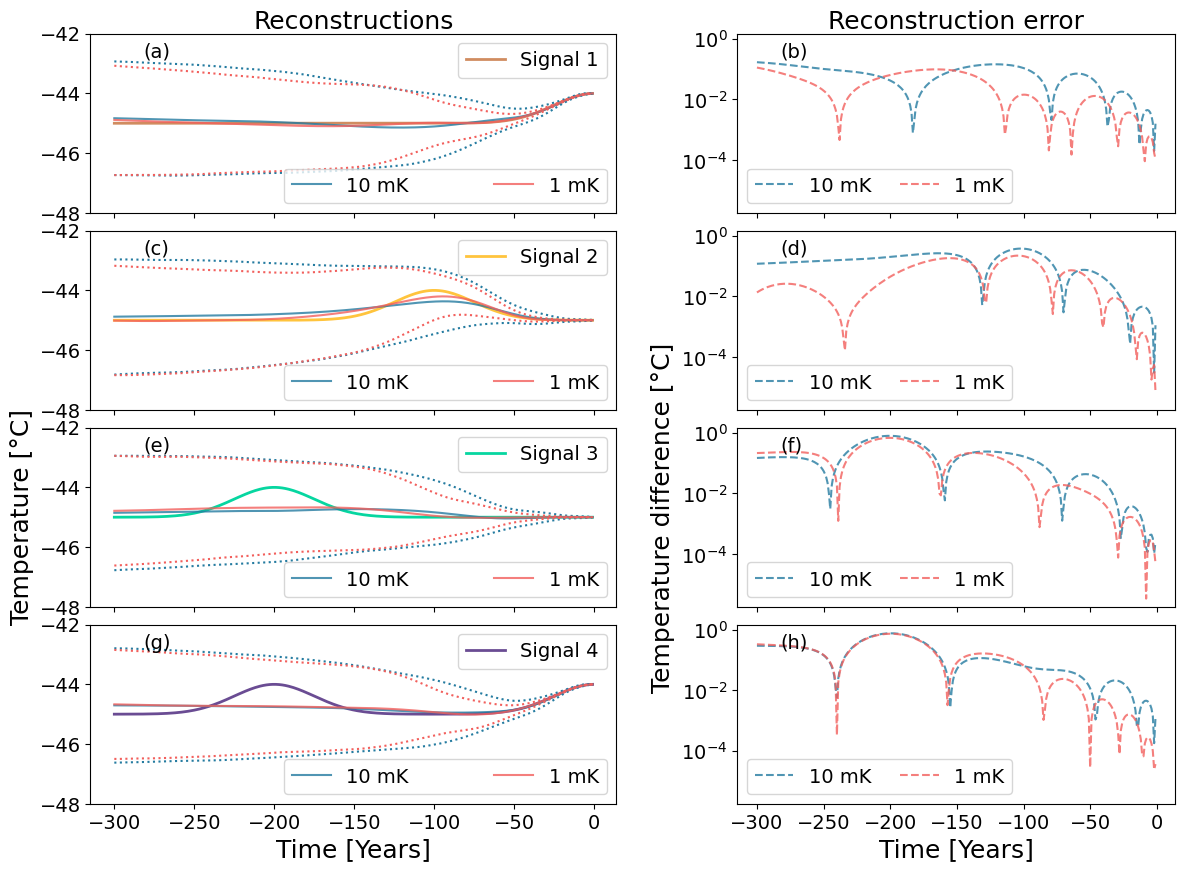

In [21]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

t_annual_500yr=np.arange(0,500,1)
signals_annual = [signal_1, signal_2, signal_3, signal_4]

x1=t_annual_500yr -500
signals = [
    signal_1,
    signal_2,
    signal_3,
    signal_4,
]

labels  = ['Signal 1', 'Signal 2', 'Signal 3', 'Signal 4']
sublabels  = ['10 mK', '1 mK']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
recon_colors  = ['#247ba0','#f25f5c']
subplotleftlabels  = ['(a)', '(c)','(e)','(g)']
subplotrightlabels  = ['(b)','(d)','(f)','(h)']

others = [
    [q_mean_artificial_signal_1_40eq_10mK,  q_mean_artificial_signal_1_40eq_1mK],
    [q_mean_artificial_signal_2_40eq_10mK,  q_mean_artificial_signal_2_40eq_1mK],
    [q_mean_artificial_signal_3_40eq_10mK,  q_mean_artificial_signal_3_40eq_1mK],
    [q_mean_artificial_signal_4_40eq_10mK,  q_mean_artificial_signal_4_40eq_1mK],
]

ci_upper = [
    [upper_bound_artificial_signal_1_40eq_10mK,  upper_bound_artificial_signal_1_40eq_1mK],
    [upper_bound_artificial_signal_2_40eq_10mK,  upper_bound_artificial_signal_2_40eq_1mK],
    [upper_bound_artificial_signal_3_40eq_10mK,  upper_bound_artificial_signal_3_40eq_1mK],
    [upper_bound_artificial_signal_4_40eq_10mK,  upper_bound_artificial_signal_4_40eq_1mK],
]

ci_lower= [
    [lower_bound_artificial_signal_1_40eq_10mK,  lower_bound_artificial_signal_1_40eq_1mK],
    [lower_bound_artificial_signal_2_40eq_10mK,  lower_bound_artificial_signal_2_40eq_1mK],
    [lower_bound_artificial_signal_3_40eq_10mK,  lower_bound_artificial_signal_3_40eq_1mK],
    [lower_bound_artificial_signal_4_40eq_10mK,  lower_bound_artificial_signal_4_40eq_1mK],
]


fig = plt.figure(figsize=(14, 10))


# Outer layout: left (stacked) + right (single)
outer_gs = GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.25)

# =========================
# LEFT PANEL: all 4 signals
# =========================
left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],
    hspace=0.1
)

left_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(left_gs[i],
                             sharex=left_axes[0],
                             sharey=left_axes[0])

    line_signal,=ax.plot(x1[-300:], signals[i][-300:],color=colors[i], label=labels[i], lw=2)

    first_legend = ax.legend(handles=[line_signal], loc='upper right',fontsize=14)
    ax.add_artist(first_legend)   
    
    line_1,=ax.plot(x1[-300:], others[i][0][-300:],
            color=recon_colors[0], label=sublabels[0],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')
    
    line_2,=ax.plot(x1[-300:], others[i][1][-300:],
            color=recon_colors[1], label=sublabels[1],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][1][-300:],
            color=recon_colors[1], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][1][-300:],
            color=recon_colors[1], linestyle='dotted')

    ax.text(0.1, 0.95, subplotleftlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    
    ax.legend(handles=[line_1,line_2],loc='lower right',fontsize=14, mode = "expand", ncol = 3,bbox_to_anchor=(0.35, 0, 0.65, 1))
   
    ax.set_ylim(-48, -42)
    left_axes.append(ax)

# Formatting
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# RIGHT PANEL: even signals
# =========================
right_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[1],
    hspace=0.1
)

right_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(right_gs[i])
    else:
        ax = fig.add_subplot(right_gs[i],
                             sharex=right_axes[0],
                             sharey=right_axes[0])

        
    ax.plot(x1[-300:], np.abs(others[i][0][-300:]-signals[i][-300:]),
            color=recon_colors[0], label=sublabels[0], alpha=0.8, linestyle='--')

    ax.plot(x1[-300:], np.abs(others[i][1][-300:]-signals[i][-300:]),
            color=recon_colors[1], label=sublabels[1], alpha=0.8, linestyle='--')

    ax.legend(loc='lower right',fontsize=14, mode = "expand", ncol = 3,bbox_to_anchor=(0, 0, 0.65, 1))
    ax.set_yscale('log')
    ax.text(0.1, 0.95, subplotrightlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    
    
    right_axes.append(ax)

# Formatting
for ax in right_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

right_axes[2].set_ylabel('Temperature difference [°C]', fontsize=18)
right_axes[-1].set_xlabel('Time [Years]', fontsize=18)


left_axes[0].text(
    0.5, 1,                
    'Reconstructions',      
    ha='center', va='bottom',    
    fontsize=18,
    transform=left_axes[0].transAxes
)

right_axes[0].text(
    0.5, 1,              
    'Reconstruction error',           
    ha='center', va='bottom',
    fontsize=18,
    transform=right_axes[0].transAxes
)

plt.savefig('Figures/fig_m_uncerstainty.png', dpi=300)
plt.show()


Results 4.4. Influence of borehole depth and temporal smearing. 

In [22]:
ics={}
with open('Forward_model/IC_ws64_wb0_tb14_H2782_a24634_ic.pkl', 'rb') as f:
    ics=dill.load(f)


In [23]:
fws_sim_signal_1=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_full_depth_signal_1.npy')
fws_sim_signal_2=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_full_depth_signal_2.npy')
fws_sim_signal_3=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_full_depth_signal_3.npy')
fws_sim_signal_4=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_full_depth_signal_4.npy')

fws_sim_signals=[fws_sim_signal_1,fws_sim_signal_2,fws_sim_signal_3,fws_sim_signal_4]


fwd_diff=[]
for i in range(4):
    diff= fws_sim_signals[i] - ics['-45.000']
    fwd_diff.append(diff)

fwd_depths= np.load('Forward_model/forward_model_depths.npy')


In [24]:
Artificial_signal_1_full_depth_1mK_upper_bound=np.load('Results/Artificial_signal_1_full_depth_1mK_upper_bound.npy')
Artificial_signal_1_full_depth_1mK_lower_bound=np.load('Results/Artificial_signal_1_full_depth_1mK_lower_bound.npy')
Artificial_signal_1_full_depth_1mK_qmean=np.load('Results/Artificial_signal_1_full_depth_1mK_qmean.npy')

Artificial_signal_2_full_depth_1mK_upper_bound=np.load('Results/Artificial_signal_2_full_depth_1mK_upper_bound.npy')
Artificial_signal_2_full_depth_1mK_lower_bound=np.load('Results/Artificial_signal_2_full_depth_1mK_lower_bound.npy')
Artificial_signal_2_full_depth_1mK_qmean=np.load('Results/Artificial_signal_2_full_depth_1mK_qmean.npy')

Artificial_signal_3_full_depth_1mK_upper_bound=np.load('Results/Artificial_signal_3_full_depth_1mK_upper_bound.npy')
Artificial_signal_3_full_depth_1mK_lower_bound=np.load('Results/Artificial_signal_3_full_depth_1mK_lower_bound.npy')
Artificial_signal_3_full_depth_1mK_qmean=np.load('Results/Artificial_signal_3_full_depth_1mK_qmean.npy')

Artificial_signal_4_full_depth_1mK_upper_bound=np.load('Results/Artificial_signal_4_full_depth_1mK_upper_bound.npy')
Artificial_signal_4_full_depth_1mK_lower_bound=np.load('Results/Artificial_signal_4_full_depth_1mK_lower_bound.npy')
Artificial_signal_4_full_depth_1mK_qmean=np.load('Results/Artificial_signal_4_full_depth_1mK_qmean.npy')


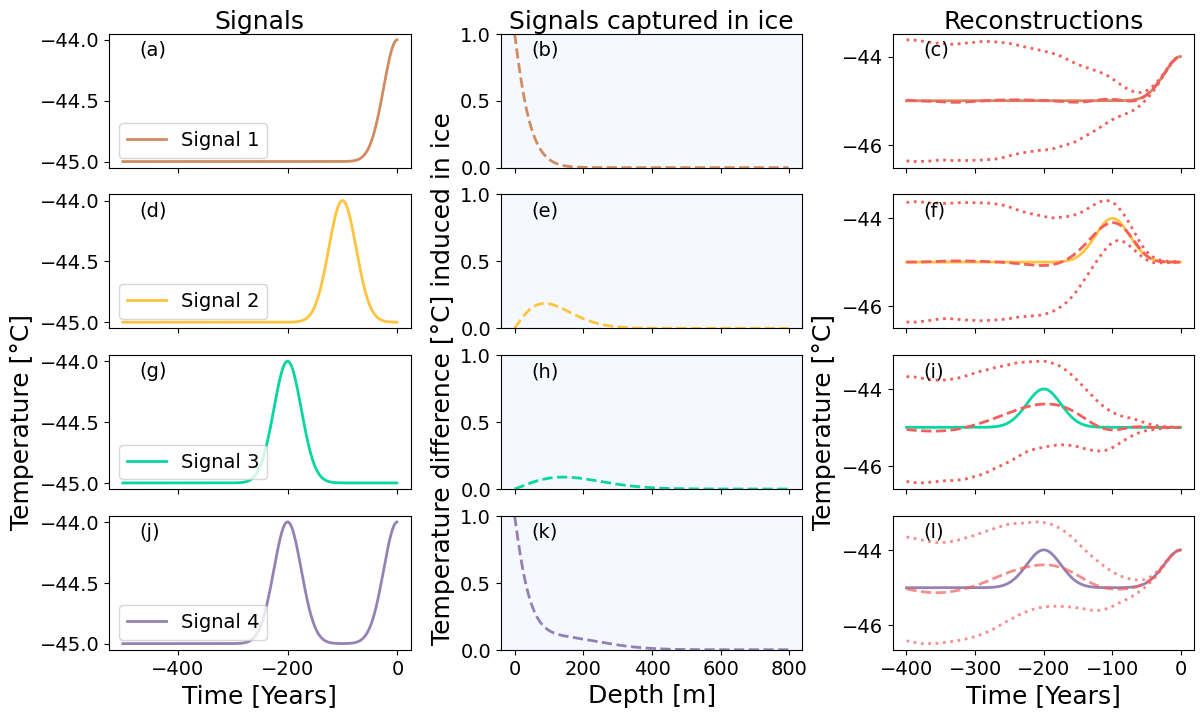

In [25]:

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(14, 8))

outer_gs = GridSpec(1, 3, width_ratios=[1, 1,1], wspace=0.3)

left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],
    hspace=0.2
)

signals = [signal_1, signal_2, signal_3, signal_4]
labels  = ['Signal 1', 'Signal 2', 'Signal 3', 'Signal 4']
colors_r  = ['#f25f5c', '#247ba0', '#50514f']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
alphas=[1,1,1,0.7]
subplotlabels1  = ['(a)', '(d)', '(g)', '(j)']
subplotlabels2  = ['(b)', '(e)', '(h)', '(k)']
subplotlabels3  = ['(c)', '(f)', '(i)', '(l)']
left_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(left_gs[i],sharex=left_axes[0])

    ax.plot(t_annual_500yr - 500, signals[i] ,
            color=colors[i], label=labels[i], alpha=alphas[i],lw=2)
    
    ax.text(0.1, 0.95, subplotlabels1[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    ax.legend(loc='lower left', fontsize=14)
    left_axes.append(ax)

# Formatting
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# MID PANEL: even signals
# =========================

# REMOVED:
# ax_mid = fig.add_subplot(outer_gs[1])

mid_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[1],
    hspace=0.2
)

mid_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(mid_gs[i])
    else:
        ax = fig.add_subplot(mid_gs[i])

    ax.plot(fwd_depths[:200], fwd_diff[i][:200],
            color=colors[i], label=labels[i], alpha=alphas[i],lw=2, linestyle='--')

    ax.set_ylim(0, 1)
    ax.text(0.1, 0.95, subplotlabels2[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    ax.set_facecolor('#F5F9FF')    
    mid_axes.append(ax)

for ax in mid_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

mid_axes[2].set_ylabel('           Temperature difference [°C] induced in ice', fontsize=18)
mid_axes[-1].set_xlabel('Depth [m]', fontsize=18)


# =========================
# RIGHT PANEL: even signals
# =========================


right_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[2],
    hspace=0.2
)

recon_signals = [Artificial_signal_1_full_depth_1mK_qmean, Artificial_signal_2_full_depth_1mK_qmean, Artificial_signal_3_full_depth_1mK_qmean, Artificial_signal_4_full_depth_1mK_qmean]
recon_upper = [Artificial_signal_1_full_depth_1mK_upper_bound, Artificial_signal_2_full_depth_1mK_upper_bound, Artificial_signal_3_full_depth_1mK_upper_bound, Artificial_signal_4_full_depth_1mK_upper_bound]
recon_lower = [Artificial_signal_1_full_depth_1mK_lower_bound, Artificial_signal_2_full_depth_1mK_lower_bound, Artificial_signal_3_full_depth_1mK_lower_bound, Artificial_signal_4_full_depth_1mK_lower_bound]
rlabels  = ['Signal 1 reconstruction', 'Signal 2 reconstruction', 'Signal 3 reconstruction', 'Signal 4 reconstruction']
right_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(right_gs[i])
    else:
        ax = fig.add_subplot(right_gs[i])


    ax.plot(t_annual_500yr[-400:]  - 500, signals[i][-400:] ,
            color=colors[i], label=rlabels[i], alpha=alphas[i],lw=2)

    ax.plot(t_annual_500yr[-400:]  - 500, recon_signals[i][-400:] ,
            color='#f25f5c', label=rlabels[i], alpha=alphas[i],lw=2,linestyle='--')
    ax.plot(t_annual_500yr[-400:]  - 500, recon_upper[i][-400:] ,           
            color='#f25f5c',  alpha=alphas[i],lw=2,linestyle='dotted')
    ax.plot(t_annual_500yr[-400:]  - 500, recon_lower[i][-400:] ,
            color='#f25f5c', alpha=alphas[i],lw=2,linestyle='dotted')
    
    ax.text(0.1, 0.95, subplotlabels3[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)

    right_axes.append(ax)

for ax in right_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

right_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
right_axes[-1].set_xlabel('Time [Years]', fontsize=18)

left_axes[0].text(
    0.5, 1,                   
    'Signals',        
    ha='center', va='bottom',    
    fontsize=18,
    transform=left_axes[0].transAxes
)

mid_axes[0].text(
    0.5, 1,                  
    'Signals captured in ice',             
    ha='center', va='bottom',
    fontsize=18,
    transform=mid_axes[0].transAxes
)

right_axes[0].text(
    0.5, 1,                   
    'Reconstructions',       
    ha='center', va='bottom',
    fontsize=18,
    transform=right_axes[0].transAxes
)

# plt.savefig('Figures/fig_temporal_smearing.png', dpi=300)

plt.show()



In [26]:
upper_bound_artificial_signal_1_40eq_30mK=np.load('Results/Artificial_signal_1_40eq_30mK_upper_bound.npy')
lower_bound_artificial_signal_1_40eq_30mK=np.load('Results/Artificial_signal_1_40eq_30mK_lower_bound.npy')
q_mean_artificial_signal_1_40eq_30mK=np.load('Results/Artificial_signal_1_40eq_30mK_qmean.npy')

upper_bound_artificial_signal_2_40eq_30mK=np.load('Results/Artificial_signal_2_40eq_30mK_upper_bound.npy')
lower_bound_artificial_signal_2_40eq_30mK=np.load('Results/Artificial_signal_2_40eq_30mK_lower_bound.npy')
q_mean_artificial_signal_2_40eq_30mK=np.load('Results/Artificial_signal_2_40eq_30mK_qmean.npy')

upper_bound_artificial_signal_3_40eq_30mK=np.load('Results/Artificial_signal_3_40eq_30mK_upper_bound.npy')
lower_bound_artificial_signal_3_40eq_30mK=np.load('Results/Artificial_signal_3_40eq_30mK_lower_bound.npy')
q_mean_artificial_signal_3_40eq_30mK=np.load('Results/Artificial_signal_3_40eq_30mK_qmean.npy')

upper_bound_artificial_signal_4_40eq_30mK=np.load('Results/Artificial_signal_4_40eq_30mK_upper_bound.npy')
lower_bound_artificial_signal_4_40eq_30mK=np.load('Results/Artificial_signal_4_40eq_30mK_lower_bound.npy')
q_mean_artificial_signal_4_40eq_30mK=np.load('Results/Artificial_signal_4_40eq_30mK_qmean.npy')

rjmcmc_time_steps=np.load('Forward_model/fwd_times_0_499.npy')

rjmcmc_analysis_artificial_signal1_q_mean=np.load('Results/A1_R10m3_q_mean_TS_1.npy')
rjmcmc_analysis_artificial_signal1_upper_bound=np.load('Results/A1_R10m3_upper_bound_TS_1.npy')
rjmcmc_analysis_artificial_signal1_lower_bound=np.load('Results/A1_R10m3_lower_bound_TS_1.npy')

rjmcmc_analysis_artificial_signal2_q_mean=np.load('Results/A1_R10m3_q_mean_TS_2.npy')
rjmcmc_analysis_artificial_signal2_upper_bound=np.load('Results/A1_R10m3_upper_bound_TS_2.npy')
rjmcmc_analysis_artificial_signal2_lower_bound=np.load('Results/A1_R10m3_lower_bound_TS_2.npy')

rjmcmc_analysis_artificial_signal3_q_mean=np.load('Results/A1_R10m3_q_mean_TS_3.npy')
rjmcmc_analysis_artificial_signal3_upper_bound=np.load('Results/A1_R10m3_upper_bound_TS_3.npy')
rjmcmc_analysis_artificial_signal3_lower_bound=np.load('Results/A1_R10m3_lower_bound_TS_3.npy')

rjmcmc_analysis_artificial_signal4_q_mean=np.load('Results/A1_R10m3_q_mean_TS_4.npy')
rjmcmc_analysis_artificial_signal4_upper_bound=np.load('Results/A1_R10m3_upper_bound_TS_4.npy')
rjmcmc_analysis_artificial_signal4_lower_bound=np.load('Results/A1_R10m3_lower_bound_TS_4.npy')



In [27]:
all_Ts_signals_1_to_4=np.load('Data/Gaussian_pulse_signals/time_series_used/all_Ts_signals_1_to_4.npy')

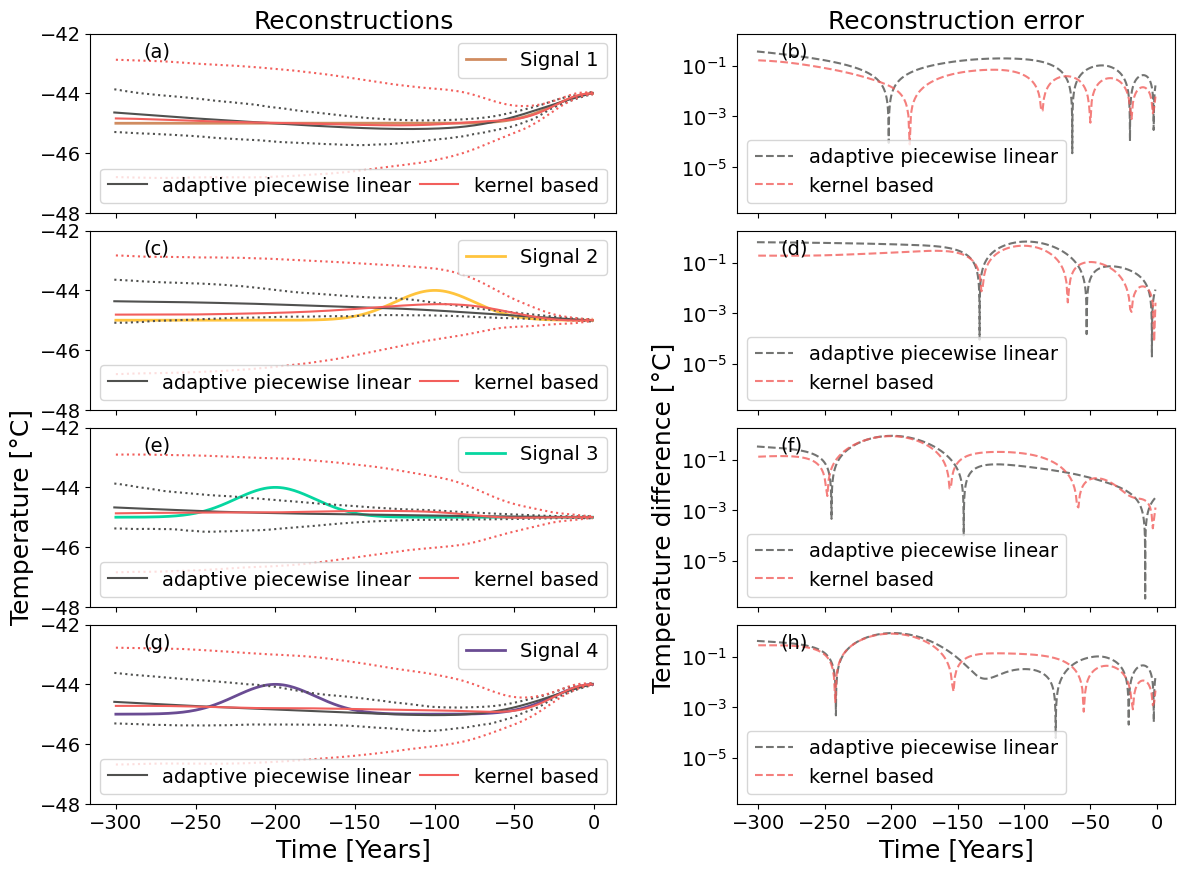

In [28]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

rjmcmc_time_steps=np.load('Forward_model/fwd_times_0_499.npy')
t_annual_500yr=np.arange(0,500,1)
signals = [signal_1, signal_2, signal_3, signal_4]
signals_fwd=[all_Ts_signals_1_to_4[0],all_Ts_signals_1_to_4[1],all_Ts_signals_1_to_4[2],all_Ts_signals_1_to_4[3]]
x=rjmcmc_time_steps-500
x1=t_annual_500yr -500

labels  = ['Signal 1', 'Signal 2', 'Signal 3', 'Signal 4']
sublabels  = ['adaptive piecewise linear', 'kernel based']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
recon_colors  = ['#50514f', '#f25f5c']
subplotleftlabels  = ['(a)', '(c)','(e)','(g)']
subplotrightlabels  = ['(b)','(d)','(f)','(h)']


others = [
    [rjmcmc_analysis_artificial_signal1_q_mean,q_mean_artificial_signal_1_40eq_30mK],
    [rjmcmc_analysis_artificial_signal2_q_mean,q_mean_artificial_signal_2_40eq_30mK],
    [rjmcmc_analysis_artificial_signal3_q_mean,q_mean_artificial_signal_3_40eq_30mK],
    [rjmcmc_analysis_artificial_signal4_q_mean,q_mean_artificial_signal_4_40eq_30mK],
]

ci_upper = [
    [rjmcmc_analysis_artificial_signal1_upper_bound,upper_bound_artificial_signal_1_40eq_30mK],
    [rjmcmc_analysis_artificial_signal2_upper_bound,upper_bound_artificial_signal_2_40eq_30mK],
    [rjmcmc_analysis_artificial_signal3_upper_bound,upper_bound_artificial_signal_3_40eq_30mK],
    [rjmcmc_analysis_artificial_signal4_upper_bound,upper_bound_artificial_signal_4_40eq_30mK],
]

ci_lower= [
    [rjmcmc_analysis_artificial_signal1_lower_bound,lower_bound_artificial_signal_1_40eq_30mK],
    [rjmcmc_analysis_artificial_signal2_lower_bound,lower_bound_artificial_signal_2_40eq_30mK],
    [rjmcmc_analysis_artificial_signal3_lower_bound,lower_bound_artificial_signal_3_40eq_30mK],
    [rjmcmc_analysis_artificial_signal4_lower_bound,lower_bound_artificial_signal_4_40eq_30mK],
]
fig = plt.figure(figsize=(14, 10))


# Outer layout: left (stacked) + right (single)
outer_gs = GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.25)

# =========================
# LEFT PANEL: all 4 signals
# =========================
left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],
    hspace=0.1
)

left_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(left_gs[i],
                             sharex=left_axes[0],
                             sharey=left_axes[0])

    line_signal,=ax.plot(x1[-300:], signals[i][-300:],color=colors[i], label=labels[i], lw=2)

    first_legend = ax.legend(handles=[line_signal], loc='upper right',fontsize=14)
    ax.add_artist(first_legend)   
    
    line_1,=ax.plot(x[-300*16:], others[i][0][-300*16:],
            color=recon_colors[0], label=sublabels[0])
    ax.plot(x[-300*16:], ci_upper[i][0][-300*16:],
            color=recon_colors[0], linestyle='dotted')
    ax.plot(x[-300*16:], ci_lower[i][0][-300*16:],
            color=recon_colors[0], linestyle='dotted')
    
    line_2,=ax.plot(x1[-300:], others[i][1][-300:],
            color=recon_colors[1], label=sublabels[1])
    ax.plot(x1[-300:], ci_upper[i][1][-300:],
            color=recon_colors[1], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][1][-300:],
            color=recon_colors[1], linestyle='dotted')

    ax.text(0.1, 0.95, subplotleftlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    
    ax.legend(handles=[line_1,line_2],loc='lower right',fontsize=14, mode = "expand", ncol = 3)#,bbox_to_anchor=(0.35, 0, 0.65, 1))
   
    ax.set_ylim(-48, -42)
    left_axes.append(ax)

# Formatting
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# RIGHT PANEL: even signals
# =========================
right_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[1],
    hspace=0.1
)

right_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(right_gs[i])
    else:
        ax = fig.add_subplot(right_gs[i],
                             sharex=right_axes[0],
                             sharey=right_axes[0])

        
    ax.plot(x[-300*16:], np.abs(others[i][0][-300*16:]-signals_fwd[i][-300*16:]),
            color=recon_colors[0], label=sublabels[0], alpha=0.8, linestyle='--')

    ax.plot(x1[-300:], np.abs(others[i][1][-300:]-signals[i][-300:]),
            color=recon_colors[1], label=sublabels[1], alpha=0.8, linestyle='--')

    ax.legend(loc='lower left',fontsize=14)
    ax.set_yscale('log')
    ax.text(0.1, 0.95, subplotrightlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    

    right_axes.append(ax)

# Formatting
for ax in right_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

right_axes[2].set_ylabel('Temperature difference [°C]', fontsize=18)
right_axes[-1].set_xlabel('Time [Years]', fontsize=18)


left_axes[0].text(
    0.5, 1,                  
    'Reconstructions',       
    ha='center', va='bottom',    
    fontsize=18,
    transform=left_axes[0].transAxes
)

right_axes[0].text(
    0.5, 1,                
    'Reconstruction error',           
    ha='center', va='bottom',
    fontsize=18,
    transform=right_axes[0].transAxes
)

# plt.savefig('Figures/fig_rjmcmc.png', dpi=300)